In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def rsr(X1, X2, r, N=100):
    p1, theta1 = X1[0:2], X1[2]
    p2, theta2 = X2[0:2], X2[2]
    
    # 1. Centers for Right-turn (CW)
    # Right turn center is at -90 degrees from heading
    c1 = p1 + np.array([r*np.sin(theta1), -r*np.cos(theta1)])
    c2 = p2 + np.array([r*np.sin(theta2), -r*np.cos(theta2)])
    
    v = c2 - c1
    L_straight = np.linalg.norm(v)
    
    # 2. Straight Segment Heading (The Anchor)
    # For RSR, the straight line is parallel to the vector between centers
    theta_straight = np.arctan2(v[1], v[0])
    
    # 3. Tangent Points
    # Tangent is at -90 deg from center-to-center vector for RSR
    t1 = c1 + np.array([r*np.cos(theta_straight + np.pi/2), 
                        r*np.sin(theta_straight + np.pi/2)])
    t2 = c2 + np.array([r*np.cos(theta_straight + np.pi/2), 
                        r*np.sin(theta_straight + np.pi/2)])
    
    # 4. Arc 1 Interpolation
    alpha_start = np.arctan2(p1[1]-c1[1], p1[0]-c1[0])
    alpha_end = np.arctan2(t1[1]-c1[1], t1[0]-c1[0])
    
    # Clockwise distance
    diff1 = (alpha_start - alpha_end) % (2 * np.pi)
    angles1 = alpha_start - np.linspace(0, diff1, N // 3)
    
    arc1_pos = np.stack([c1[0] + r*np.cos(angles1), c1[1] + r*np.sin(angles1)], axis=1)
    # Heading is angle of radius - 90 deg for CW
    arc1_heads = angles1 - np.pi/2

    # 5. Straight Interpolation
    straight_pos = np.linspace(t1, t2, N // 3)
    straight_heads = np.full(N // 3, theta_straight)

    # 6. Arc 2 Interpolation
    beta_start = np.arctan2(t2[1]-c2[1], t2[0]-c2[0])
    beta_end = np.arctan2(p2[1]-c2[1], p2[0]-c2[0])
    
    diff2 = (beta_start - beta_end) % (2 * np.pi)
    angles2 = beta_start - np.linspace(0, diff2, N // 3)
    
    arc2_pos = np.stack([c2[0] + r*np.cos(angles2), c2[1] + r*np.sin(angles2)], axis=1)
    arc2_heads = angles2 - np.pi/2

    # 7. Final Assembly with Clean Normalization
    all_pos = np.vstack([arc1_pos, straight_pos, arc2_pos])
    all_heads = np.concatenate([arc1_heads, straight_heads, arc2_heads])
    
    # Normalize headings to [-pi, pi] and ensure no 180-degree flips
    final_heads = np.arctan2(np.sin(all_heads), np.cos(all_heads))
    
    full_path = np.column_stack([all_pos, final_heads])
    total_length = r*diff1 + L_straight + r*diff2
    
    return 'RSR', full_path, total_length

In [3]:
def lsl(X1, X2, r, N=100):
    p1, theta1 = X1[0:2], X1[2]
    p2, theta2 = X2[0:2], X2[2]
    
    # 1. Centers for Right-turn (CW)
    # Left turn center is at +90 degrees from heading
    c1 = p1 + np.array([-r*np.sin(theta1), r*np.cos(theta1)])
    c2 = p2 + np.array([-r*np.sin(theta2), r*np.cos(theta2)])
    
    v = c2 - c1
    L_straight = np.linalg.norm(v)
    
    # 2. Straight Segment Heading (The Anchor)
    # For RSR, the straight line is parallel to the vector between centers
    theta_straight = np.arctan2(v[1], v[0])
    
    # 3. Tangent Points
    # Tangent is at -90 deg from center-to-center vector for LSL
    t1 = c1 + np.array([r*np.cos(theta_straight - np.pi/2), 
                        r*np.sin(theta_straight - np.pi/2)])
    t2 = c2 + np.array([r*np.cos(theta_straight - np.pi/2), 
                        r*np.sin(theta_straight - np.pi/2)])
    
    # 4. Arc 1 Interpolation
    alpha_start = np.arctan2(p1[1]-c1[1], p1[0]-c1[0])
    alpha_end = np.arctan2(t1[1]-c1[1], t1[0]-c1[0])
    
    # Clockwise distance
    diff1 = (alpha_end - alpha_start) % (2 * np.pi)
    angles1 = alpha_start + np.linspace(0, diff1, N // 3)
    
    arc1_pos = np.stack([c1[0] + r*np.cos(angles1), c1[1] + r*np.sin(angles1)], axis=1)
    # Heading is angle of radius - 90 deg for CW
    arc1_heads = angles1 + np.pi/2

    # 5. Straight Interpolation
    straight_pos = np.linspace(t1, t2, N // 3)
    straight_heads = np.full(N // 3, theta_straight)

    # 6. Arc 2 Interpolation
    beta_start = np.arctan2(t2[1]-c2[1], t2[0]-c2[0])
    beta_end = np.arctan2(p2[1]-c2[1], p2[0]-c2[0])
    
    diff2 = (beta_end - beta_start) % (2 * np.pi)
    angles2 = beta_start + np.linspace(0, diff2, N // 3)
    
    arc2_pos = np.stack([c2[0] + r*np.cos(angles2), c2[1] + r*np.sin(angles2)], axis=1)
    arc2_heads = angles2 + np.pi/2

    # 7. Final Assembly with Clean Normalization
    all_pos = np.vstack([arc1_pos, straight_pos, arc2_pos])
    all_heads = np.concatenate([arc1_heads, straight_heads, arc2_heads])
    
    # Normalize headings to [-pi, pi] and ensure no 180-degree flips
    final_heads = np.arctan2(np.sin(all_heads), np.cos(all_heads))
    
    full_path = np.column_stack([all_pos, final_heads])
    total_length = r*diff1 + L_straight + r*diff2
    
    return 'LSL', full_path, total_length

In [ ]:
def _mod2pi(a: float) -> float:
    return (a % (2.0*np.pi))

def _sample_arc(center, ang0, delta, turn, n):
    """
    center: (2,)
    ang0  : angle(center -> start point)
    delta : positive arc angle magnitude (rad)
    turn  : 'R' (clockwise) or 'L' (ccw)
    n     : number of samples (>=2)
    returns: (n,3) [x,y,theta]
    """
    center = np.asarray(center, dtype=float)

    if n <= 1:
        n = 2

    s = np.linspace(0.0, delta, n)
    if turn.upper() == 'R':
        ang = ang0 - s                 # clockwise
        theta = ang - 0.5*np.pi        # heading tangent to circle (CW)
    else:
        ang = ang0 + s                 # ccw
        theta = ang + 0.5*np.pi        # heading tangent to circle (CCW)

    xy = center[None, :] + np.column_stack([np.cos(ang), np.sin(ang)])
    out = np.column_stack([xy, _mod2pi(theta)])
    return out

def _sample_straight(p_from, p_to, n):
    """
    returns: (n,3) [x,y,theta]
    """
    p_from = np.asarray(p_from, dtype=float)
    p_to   = np.asarray(p_to, dtype=float)

    if n <= 1:
        n = 2

    t = np.linspace(0.0, 1.0, n)
    xy = (1.0 - t)[:, None]*p_from[None, :] + t[:, None]*p_to[None, :]
    th = np.arctan2(p_to[1]-p_from[1], p_to[0]-p_from[0])
    out = np.column_stack([xy, np.full((n,), _mod2pi(th))])
    return out

def rsl(X1, X2, r, N=100):
    """
    Dubins RSL (Right arc, Straight, Left arc)
    X1, X2: [x, y, theta] (theta in rad)
    r     : turning radius
    N     : total samples along the full path

    returns: ('RSL', full_path (Nx3), total_length)
    """
    X1 = np.asarray(X1, dtype=float).reshape(3,)
    X2 = np.asarray(X2, dtype=float).reshape(3,)

    p1, theta1 = X1[0:2], float(X1[2])
    p2, theta2 = X2[0:2], float(X2[2])
    r = float(r)

    # Turning circle centers
    # Right-turn center is to the right of heading: +r*[sin(th), -cos(th)]
    c1 = p1 + r*np.array([np.sin(theta1), -np.cos(theta1)])
    # Left-turn center is to the left of heading: +r*[-sin(th), +cos(th)]
    c2 = p2 + r*np.array([-np.sin(theta2),  np.cos(theta2)])

    dvec = c2 - c1
    d = float(np.hypot(dvec[0], dvec[1]))

    # RSL uses the internal tangent between opposite-turn circles (requires d >= 2r)
    if d < 2.0*r:
        return 'RSL', None, np.inf

    v = dvec / d
    perp = np.array([-v[1], v[0]])

    # internal tangent geometry (treat r2 = -r)
    phi = np.arccos((2.0*r)/d)  # in [0, pi/2]
    # Two possible internal tangents: +/- phi
    candidates = []
    for sgn in (+1.0, -1.0):
        u = v*np.cos(phi) + perp*(sgn*np.sin(phi))  # unit direction from c1 to tangent point on circle1
        t1 = c1 + r*u
        t2 = c2 - r*u

        # Angles from centers to relevant points
        ang_p1 = np.arctan2(p1[1]-c1[1], p1[0]-c1[0])
        ang_t1 = np.arctan2(t1[1]-c1[1], t1[0]-c1[0])

        ang_t2 = np.arctan2(t2[1]-c2[1], t2[0]-c2[0])
        ang_p2 = np.arctan2(p2[1]-c2[1], p2[0]-c2[0])

        # Right arc: clockwise from p1 to t1
        dR = _mod2pi(ang_p1 - ang_t1)
        # Left arc: ccw from t2 to p2
        dL = _mod2pi(ang_p2 - ang_t2)

        L1 = r * dR
        L2 = float(np.hypot(t2[0]-t1[0], t2[1]-t1[1]))
        L3 = r * dL
        Ltot = L1 + L2 + L3

        candidates.append((Ltot, L1, L2, L3, t1, t2, ang_p1, ang_t1, ang_t2, ang_p2))

    # pick shortest feasible of the two tangents
    Ltot, L1, L2, L3, t1, t2, ang_p1, ang_t1, ang_t2, ang_p2 = min(candidates, key=lambda x: x[0])

    # Sampling allocation (ensure each segment has at least 2 points)
    if not np.isfinite(Ltot) or Ltot <= 0:
        return 'RSL', None, np.inf

    # Proportional split, with guards
    n1 = max(2, int(round(N * (L1 / Ltot))))
    n2 = max(2, int(round(N * (L2 / Ltot))))
    n3 = max(2, N - n1 - n2)
    # If rounding made n3 too small, fix by stealing from the longest segment
    while n1 + n2 + n3 < N:
        # add to straight by default
        n2 += 1
    while n1 + n2 + n3 > N:
        # remove from the largest n among (n1,n2,n3) but keep >=2
        idx = int(np.argmax([n1, n2, n3]))
        if idx == 0 and n1 > 2: n1 -= 1
        elif idx == 1 and n2 > 2: n2 -= 1
        elif idx == 2 and n3 > 2: n3 -= 1
        else:
            break

    # Build sampled path (avoid duplicate join points by dropping the first point of later segments)
    arc1 = _sample_arc(c1, ang_p1, _mod2pi(ang_p1 - ang_t1), 'R', n1)
    straight = _sample_straight(t1, t2, n2)[1:, :]
    arc3 = _sample_arc(c2, ang_t2, _mod2pi(ang_p2 - ang_t2), 'L', n3)[1:, :]

    # Fix radii in arc sampler: it currently uses unit radius; scale positions by r about center
    # (Implemented by rewriting arc sampler output here for clarity.)
    def _rescale_arc_points(arc, center, r, turn):
        center = np.asarray(center, dtype=float)
        # Recover angles from positions (unit circle output)
        # arc[:,0:2] = center + [cos ang, sin ang]
        ang = np.arctan2(arc[:,1] - center[1], arc[:,0] - center[0])
        xy = center[None, :] + r*np.column_stack([np.cos(ang), np.sin(ang)])
        if turn.upper() == 'R':
            th = _mod2pi(ang - 0.5*np.pi)
        else:
            th = _mod2pi(ang + 0.5*np.pi)
        return np.column_stack([xy, th])

    arc1 = _rescale_arc_points(arc1, c1, r, 'R')
    arc3 = _rescale_arc_points(arc3, c2, r, 'L')

    full_path = np.vstack([arc1, straight, arc3])
    return 'RSL', full_path, Ltot


In [ ]:
# def _mod2pi(a: float) -> float:
#     return (a % (2.0*np.pi))

# def _sample_arc(center, ang0, delta, turn, n):
#     """
#     Unit-radius arc sampler; will be rescaled to radius r by caller.
#     center: (2,)
#     ang0  : angle(center -> start point)
#     delta : positive arc angle magnitude (rad)
#     turn  : 'R' (clockwise) or 'L' (ccw)
#     n     : number of samples (>=2)
#     returns: (n,3) [x,y,theta] with unit radius around center
#     """
#     center = np.asarray(center, dtype=float)

#     if n <= 1:
#         n = 2

#     s = np.linspace(0.0, delta, n)
#     if turn.upper() == 'R':
#         ang = ang0 - s
#         theta = ang - 0.5*np.pi
#     else:
#         ang = ang0 + s
#         theta = ang + 0.5*np.pi

#     xy = center[None, :] + np.column_stack([np.cos(ang), np.sin(ang)])
#     out = np.column_stack([xy, _mod2pi(theta)])
#     return out

def _rescale_arc_points(arc, center, r, turn):
    center = np.asarray(center, dtype=float)
    ang = np.arctan2(arc[:,1] - center[1], arc[:,0] - center[0])
    xy = center[None, :] + r*np.column_stack([np.cos(ang), np.sin(ang)])
    if turn.upper() == 'R':
        th = _mod2pi(ang - 0.5*np.pi)
    else:
        th = _mod2pi(ang + 0.5*np.pi)
    return np.column_stack([xy, th])

# def _sample_straight(p_from, p_to, n):
#     p_from = np.asarray(p_from, dtype=float)
#     p_to   = np.asarray(p_to, dtype=float)

#     if n <= 1:
#         n = 2

#     t = np.linspace(0.0, 1.0, n)
#     xy = (1.0 - t)[:, None]*p_from[None, :] + t[:, None]*p_to[None, :]
#     th = np.arctan2(p_to[1]-p_from[1], p_to[0]-p_from[0])
#     out = np.column_stack([xy, np.full((n,), _mod2pi(th))])
#     return out

def lsr(X1, X2, r, N=100):
    """
    Dubins LSR (Left arc, Straight, Right arc)
    X1, X2: [x, y, theta] (theta in rad)
    r     : turning radius
    N     : total samples along the full path

    returns: ('LSR', full_path (Nx3), total_length)
    """
    X1 = np.asarray(X1, dtype=float).reshape(3,)
    X2 = np.asarray(X2, dtype=float).reshape(3,)

    p1, theta1 = X1[0:2], float(X1[2])
    p2, theta2 = X2[0:2], float(X2[2])
    r = float(r)

    # Turning circle centers
    # Left-turn center: +r*[-sin(th), +cos(th)]
    c1 = p1 + r*np.array([-np.sin(theta1),  np.cos(theta1)])
    # Right-turn center: +r*[sin(th), -cos(th)]
    c2 = p2 + r*np.array([ np.sin(theta2), -np.cos(theta2)])

    dvec = c2 - c1
    d = float(np.hypot(dvec[0], dvec[1]))

    # LSR uses the internal tangent between opposite-turn circles (requires d >= 2r)
    if d < 2.0*r:
        return 'LSR', None, np.inf

    v = dvec / d
    perp = np.array([-v[1], v[0]])

    # internal tangent geometry (r2 = -r)
    phi = np.arccos((2.0*r)/d)
    candidates = []
    for sgn in (+1.0, -1.0):
        u = v*np.cos(phi) + perp*(sgn*np.sin(phi))  # unit direction from c1 to tangent point on circle1
        t1 = c1 + r*u
        t2 = c2 - r*u

        # Angles from centers
        ang_p1 = np.arctan2(p1[1]-c1[1], p1[0]-c1[0])
        ang_t1 = np.arctan2(t1[1]-c1[1], t1[0]-c1[0])

        ang_t2 = np.arctan2(t2[1]-c2[1], t2[0]-c2[0])
        ang_p2 = np.arctan2(p2[1]-c2[1], p2[0]-c2[0])

        # Left arc: ccw from p1 to t1
        dL = _mod2pi(ang_t1 - ang_p1)
        # Right arc: clockwise from t2 to p2
        dR = _mod2pi(ang_t2 - ang_p2)

        L1 = r * dL
        L2 = float(np.hypot(t2[0]-t1[0], t2[1]-t1[1]))
        L3 = r * dR
        Ltot = L1 + L2 + L3

        candidates.append((Ltot, L1, L2, L3, t1, t2, ang_p1, ang_t1, ang_t2, ang_p2))

    Ltot, L1, L2, L3, t1, t2, ang_p1, ang_t1, ang_t2, ang_p2 = min(candidates, key=lambda x: x[0])

    if not np.isfinite(Ltot) or Ltot <= 0:
        return 'LSR', None, np.inf

    # Sampling allocation
    n1 = max(2, int(round(N * (L1 / Ltot))))
    n2 = max(2, int(round(N * (L2 / Ltot))))
    n3 = max(2, N - n1 - n2)
    while n1 + n2 + n3 < N:
        n2 += 1
    while n1 + n2 + n3 > N:
        idx = int(np.argmax([n1, n2, n3]))
        if idx == 0 and n1 > 2: n1 -= 1
        elif idx == 1 and n2 > 2: n2 -= 1
        elif idx == 2 and n3 > 2: n3 -= 1
        else:
            break

    # Build path (drop duplicate join points)
    arc1 = _sample_arc(c1, ang_p1, _mod2pi(ang_t1 - ang_p1), 'L', n1)
    straight = _sample_straight(t1, t2, n2)[1:, :]
    arc3 = _sample_arc(c2, ang_t2, _mod2pi(ang_t2 - ang_p2), 'R', n3)[1:, :]

    # rescale arcs to radius r
    arc1 = _rescale_arc_points(arc1, c1, r, 'L')
    arc3 = _rescale_arc_points(arc3, c2, r, 'R')

    full_path = np.vstack([arc1, straight, arc3])
    return 'LSR', full_path, Ltot


In [6]:
# def _mod2pi(a: float) -> float:
#     return (a % (2.0*np.pi))

# def _sample_arc(center, ang0, delta, turn, n):
#     """
#     Unit-radius arc sampler; caller rescales to radius r.
#     center: (2,)
#     ang0  : angle(center -> start point)
#     delta : positive arc angle magnitude (rad)
#     turn  : 'R' (clockwise) or 'L' (ccw)
#     n     : number of samples (>=2)
#     returns: (n,3) [x,y,theta] with unit radius around center
#     """
#     center = np.asarray(center, dtype=float)
#     n = max(2, int(n))

#     s = np.linspace(0.0, delta, n)
#     if turn.upper() == 'R':
#         ang = ang0 - s
#         theta = ang - 0.5*np.pi
#     else:
#         ang = ang0 + s
#         theta = ang + 0.5*np.pi

#     xy = center[None, :] + np.column_stack([np.cos(ang), np.sin(ang)])
#     return np.column_stack([xy, _mod2pi(theta)])

# def _rescale_arc_points(arc, center, r, turn):
#     center = np.asarray(center, dtype=float)
#     ang = np.arctan2(arc[:, 1] - center[1], arc[:, 0] - center[0])
#     xy = center[None, :] + r*np.column_stack([np.cos(ang), np.sin(ang)])
#     if turn.upper() == 'R':
#         th = _mod2pi(ang - 0.5*np.pi)
#     else:
#         th = _mod2pi(ang + 0.5*np.pi)
#     return np.column_stack([xy, th])

def rlr(X1, X2, r, N=100):
    """
    Dubins RLR (Right arc, Left arc, Right arc)
    X1, X2: [x, y, theta] (theta in rad)
    r     : turning radius
    N     : total samples along the full path

    returns: ('RLR', full_path (Nx3), total_length)
    """
    X1 = np.asarray(X1, dtype=float).reshape(3,)
    X2 = np.asarray(X2, dtype=float).reshape(3,)
    p1, th1 = X1[0:2], float(X1[2])
    p2, th2 = X2[0:2], float(X2[2])
    r = float(r)

    # Right-turn circle centers at start and end
    c1 = p1 + r*np.array([np.sin(th1), -np.cos(th1)])
    c2 = p2 + r*np.array([np.sin(th2), -np.cos(th2)])

    dvec = c2 - c1
    d = float(np.hypot(dvec[0], dvec[1]))

    # For RLR, the intermediate (left) circle center must be at distance 2r from BOTH c1 and c2
    # => intersection of circles radius 2r around c1 and c2 exists only if d <= 4r
    if d > 4.0*r or d < 1e-12:
        return 'RLR', None, np.inf

    R = 2.0*r
    v = dvec / d
    perp = np.array([-v[1], v[0]])
    mid = 0.5*(c1 + c2)

    # circle-circle intersection (equal radii)
    a = 0.5*d
    h2 = R*R - a*a
    if h2 < 0.0:
        return 'RLR', None, np.inf
    h = float(np.sqrt(max(0.0, h2)))

    cM_candidates = [mid + h*perp, mid - h*perp]

    best = None
    for cM in cM_candidates:
        cM = np.asarray(cM, dtype=float)

        # Switch points are the external tangency points between circles whose centers are 2r apart
        u12 = (cM - c1) / np.linalg.norm(cM - c1)   # |cM-c1| = 2r
        u23 = (cM - c2) / np.linalg.norm(cM - c2)   # |cM-c2| = 2r

        s12 = c1 + r*u12     # point on start right circle and middle left circle
        s23 = c2 + r*u23     # point on end right circle and middle left circle

        # Angles (center -> point)
        ang_p1_c1  = np.arctan2(p1[1]-c1[1],  p1[0]-c1[0])
        ang_s12_c1 = np.arctan2(s12[1]-c1[1], s12[0]-c1[0])

        ang_s12_cM = np.arctan2(s12[1]-cM[1], s12[0]-cM[0])
        ang_s23_cM = np.arctan2(s23[1]-cM[1], s23[0]-cM[0])

        ang_s23_c2 = np.arctan2(s23[1]-c2[1], s23[0]-c2[0])
        ang_p2_c2  = np.arctan2(p2[1]-c2[1],  p2[0]-c2[0])

        # Arc angles
        dR1 = _mod2pi(ang_p1_c1 - ang_s12_c1)        # Right: clockwise p1 -> s12
        dL  = _mod2pi(ang_s23_cM - ang_s12_cM)       # Left : ccw      s12 -> s23
        dR2 = _mod2pi(ang_s23_c2 - ang_p2_c2)        # Right: clockwise s23 -> p2

        L1, L2, L3 = r*dR1, r*dL, r*dR2
        Ltot = L1 + L2 + L3

        cand = (Ltot, L1, L2, L3, cM, ang_p1_c1, dR1, ang_s12_cM, dL, ang_s23_c2, dR2, c1, c2)
        if best is None or cand[0] < best[0]:
            best = cand

    if best is None or not np.isfinite(best[0]) or best[0] <= 0.0:
        return 'RLR', None, np.inf

    Ltot, L1, L2, L3, cM, ang_p1_c1, dR1, ang_s12_cM, dL, ang_s23_c2, dR2, c1, c2 = best

    # Sampling allocation across 3 arcs
    n1 = max(2, int(round(N * (L1 / Ltot))))
    n2 = max(2, int(round(N * (L2 / Ltot))))
    n3 = max(2, N - n1 - n2)
    while n1 + n2 + n3 < N:
        n2 += 1
    while n1 + n2 + n3 > N:
        idx = int(np.argmax([n1, n2, n3]))
        if idx == 0 and n1 > 2: n1 -= 1
        elif idx == 1 and n2 > 2: n2 -= 1
        elif idx == 2 and n3 > 2: n3 -= 1
        else:
            break

    # Build path (drop duplicate join points)
    arc1_u = _sample_arc(c1, ang_p1_c1, dR1, 'R', n1)
    arc2_u = _sample_arc(cM, ang_s12_cM, dL,  'L', n2)[1:, :]
    arc3_u = _sample_arc(c2, ang_s23_c2, dR2, 'R', n3)[1:, :]

    arc1 = _rescale_arc_points(arc1_u, c1, r, 'R')
    arc2 = _rescale_arc_points(arc2_u, cM, r, 'L')
    arc3 = _rescale_arc_points(arc3_u, c2, r, 'R')

    full_path = np.vstack([arc1, arc2, arc3])
    return 'RLR', full_path, Ltot


In [7]:
# def _mod2pi(a: float) -> float:
#     return (a % (2.0*np.pi))

# def _sample_arc(center, ang0, delta, turn, n):
#     """
#     Unit-radius arc sampler; caller rescales to radius r.
#     center: (2,)
#     ang0  : angle(center -> start point)
#     delta : positive arc angle magnitude (rad)
#     turn  : 'R' (clockwise) or 'L' (ccw)
#     n     : number of samples (>=2)
#     returns: (n,3) [x,y,theta] with unit radius around center
#     """
#     center = np.asarray(center, dtype=float)
#     n = max(2, int(n))

#     s = np.linspace(0.0, delta, n)
#     if turn.upper() == 'R':
#         ang = ang0 - s
#         theta = ang - 0.5*np.pi
#     else:
#         ang = ang0 + s
#         theta = ang + 0.5*np.pi

#     xy = center[None, :] + np.column_stack([np.cos(ang), np.sin(ang)])
#     return np.column_stack([xy, _mod2pi(theta)])

# def _rescale_arc_points(arc, center, r, turn):
#     center = np.asarray(center, dtype=float)
#     ang = np.arctan2(arc[:, 1] - center[1], arc[:, 0] - center[0])
#     xy = center[None, :] + r*np.column_stack([np.cos(ang), np.sin(ang)])
#     if turn.upper() == 'R':
#         th = _mod2pi(ang - 0.5*np.pi)
#     else:
#         th = _mod2pi(ang + 0.5*np.pi)
#     return np.column_stack([xy, th])

def lrl(X1, X2, r, N=100):
    """
    Dubins LRL (Left arc, Right arc, Left arc)
    X1, X2: [x, y, theta] (theta in rad)
    r     : turning radius
    N     : total samples along the full path

    returns: ('LRL', full_path (Nx3), total_length)
    """
    X1 = np.asarray(X1, dtype=float).reshape(3,)
    X2 = np.asarray(X2, dtype=float).reshape(3,)
    p1, th1 = X1[0:2], float(X1[2])
    p2, th2 = X2[0:2], float(X2[2])
    r = float(r)

    # Left-turn circle centers at start and end
    c1 = p1 + r*np.array([-np.sin(th1),  np.cos(th1)])
    c2 = p2 + r*np.array([-np.sin(th2),  np.cos(th2)])

    dvec = c2 - c1
    d = float(np.hypot(dvec[0], dvec[1]))

    # For LRL, the intermediate (right) circle center must be at distance 2r from BOTH c1 and c2
    # => intersection of circles radius 2r around c1 and c2 exists only if d <= 4r
    if d > 4.0*r or d < 1e-12:
        return 'LRL', None, np.inf

    R = 2.0*r
    v = dvec / d
    perp = np.array([-v[1], v[0]])
    mid = 0.5*(c1 + c2)

    # circle-circle intersection (equal radii)
    a = 0.5*d
    h2 = R*R - a*a
    if h2 < 0.0:
        return 'LRL', None, np.inf
    h = float(np.sqrt(max(0.0, h2)))

    cM_candidates = [mid + h*perp, mid - h*perp]

    best = None
    for cM in cM_candidates:
        cM = np.asarray(cM, dtype=float)

        # Switch points are the external tangency points between circles whose centers are 2r apart
        u12 = (cM - c1) / np.linalg.norm(cM - c1)   # |cM-c1| = 2r
        u23 = (cM - c2) / np.linalg.norm(cM - c2)   # |cM-c2| = 2r

        s12 = c1 + r*u12     # point on start left circle and middle right circle
        s23 = c2 + r*u23     # point on end left circle and middle right circle

        # Angles (center -> point)
        ang_p1_c1  = np.arctan2(p1[1]-c1[1],  p1[0]-c1[0])
        ang_s12_c1 = np.arctan2(s12[1]-c1[1], s12[0]-c1[0])

        ang_s12_cM = np.arctan2(s12[1]-cM[1], s12[0]-cM[0])
        ang_s23_cM = np.arctan2(s23[1]-cM[1], s23[0]-cM[0])

        ang_s23_c2 = np.arctan2(s23[1]-c2[1], s23[0]-c2[0])
        ang_p2_c2  = np.arctan2(p2[1]-c2[1],  p2[0]-c2[0])

        # Arc angles
        dL1 = _mod2pi(ang_s12_c1 - ang_p1_c1)        # Left : ccw      p1 -> s12
        dR  = _mod2pi(ang_s12_cM - ang_s23_cM)       # Right: clockwise s12 -> s23
        dL2 = _mod2pi(ang_p2_c2 - ang_s23_c2)        # Left : ccw      s23 -> p2

        L1, L2, L3 = r*dL1, r*dR, r*dL2
        Ltot = L1 + L2 + L3

        cand = (Ltot, L1, L2, L3, cM, ang_p1_c1, dL1, ang_s12_cM, dR, ang_s23_c2, dL2, c1, c2)
        if best is None or cand[0] < best[0]:
            best = cand

    if best is None or not np.isfinite(best[0]) or best[0] <= 0.0:
        return 'LRL', None, np.inf

    Ltot, L1, L2, L3, cM, ang_p1_c1, dL1, ang_s12_cM, dR, ang_s23_c2, dL2, c1, c2 = best

    # Sampling allocation across 3 arcs
    n1 = max(2, int(round(N * (L1 / Ltot))))
    n2 = max(2, int(round(N * (L2 / Ltot))))
    n3 = max(2, N - n1 - n2)
    while n1 + n2 + n3 < N:
        n2 += 1
    while n1 + n2 + n3 > N:
        idx = int(np.argmax([n1, n2, n3]))
        if idx == 0 and n1 > 2: n1 -= 1
        elif idx == 1 and n2 > 2: n2 -= 1
        elif idx == 2 and n3 > 2: n3 -= 1
        else:
            break

    # Build path (drop duplicate join points)
    arc1_u = _sample_arc(c1, ang_p1_c1, dL1, 'L', n1)
    arc2_u = _sample_arc(cM, ang_s12_cM, dR,  'R', n2)[1:, :]
    arc3_u = _sample_arc(c2, ang_s23_c2, dL2, 'L', n3)[1:, :]

    arc1 = _rescale_arc_points(arc1_u, c1, r, 'L')
    arc2 = _rescale_arc_points(arc2_u, cM, r, 'R')
    arc3 = _rescale_arc_points(arc3_u, c2, r, 'L')

    full_path = np.vstack([arc1, arc2, arc3])
    return 'LRL', full_path, Ltot


In [8]:
def dubins_path(X1, X2, r, N=100):
    # Measure distance between centers d
    dist_btw_ctr = np.sqrt((X1[0]-X2[0])**2 + (X1[1]-X2[1])**2)
    
    # Checking criteria for reduced computation
    # Always check RSR, LSL
    # Check RSL, LSR IFF d >= 2R
    # Check RLR, LRL IFF d < 4R
    rsr_type, rsr_path, rsr_length = rsr(X1, X2, r, N)
    lsl_type, lsl_path, lsl_length = lsl(X1, X2, r, N)
    if dist_btw_ctr < 4*r:
        rlr_type, rlr_path, rlr_length = rlr(X1, X2, r, N)
        lrl_type, lrl_path, lrl_length = lrl(X1, X2, r, N)
    else:
        rlr_type, rlr_path, rlr_length = 'RLR', None, 1e100
        lrl_type, lrl_path, lrl_length = 'LRL', None, 1e100
    if dist_btw_ctr >= 2*r:
        rsl_type, rsl_path, rsl_length = rsl(X1, X2, r, N)
        lsr_type, lsr_path, lsr_length = lsr(X1, X2, r, N)
    else:
        rsl_type, rsl_path, rsl_length = 'RSL', None, 1e100
        lsr_type, lsr_path, lsr_length = 'LSR', None, 1e100
        
    # Check find shortest path
    path_type_vec = [rsr_type, lsl_type, rlr_type, lrl_type, rsl_type, lsr_type]
    path_length_vec = [rsr_length, lsl_length, rlr_length, lrl_length, rsl_length, lsr_length]
    minimum_path_index = path_length_vec.index(np.min(path_length_vec))
    min_dubins = path_type_vec[minimum_path_index]
    
    if min_dubins == rsr_type:
        return rsr_type, rsr_path, rsr_length
    elif min_dubins == lsl_type:
        return lsl_type, lsl_path, lsl_length
    elif min_dubins == rlr_type:
        return rlr_type, rlr_path, rlr_length
    elif min_dubins == lrl_type:
        return lrl_type, lrl_path, lrl_length
    elif min_dubins == rsl_type:
        return rsl_type, rsl_path, rsl_length
    else:
        return lsr_type, lsr_path, lsr_length

In [9]:
x1 = [0, 0, np.deg2rad(90)]
x2 = [20, 10, np.deg2rad(180)]
r_min = 3
N = 100

RSL
31.16635358641629


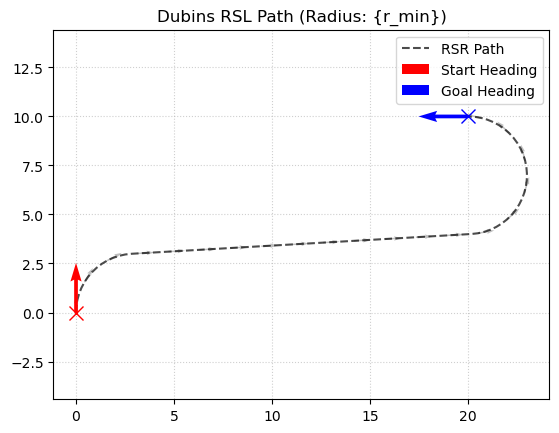

In [10]:
path_type, path, path_length = dubins_path(x1, x2, r_min, N=100)
print(path_type)
print(path_length)

# 1. Setup Figure
fig = plt.figure()

# 2. Plot the path
plt.plot(path[:,0], path[:,1], '--k', label='RSR Path', alpha=0.7)

# 3. Mark start (red) and goal (blue) points
plt.plot(x1[0], x1[1], 'xr', markersize=10)
plt.plot(x2[0], x2[1], 'xb', markersize=10)

# 4. Add Quiver for Initial and Final Headings
# We use scale_units='dots' or 'xy' to ensure the arrows are visible
plt.quiver(x1[0], x1[1], np.cos(x1[2]), np.sin(x1[2]), 
           color='red', scale=10, label='Start Heading', zorder=5)

plt.quiver(x2[0], x2[1], np.cos(x2[2]), np.sin(x2[2]), 
           color='blue', scale=10, label='Goal Heading', zorder=5)

# 5. Optional: Add small arrows along the path to check for heading jumps
# Plotting every 5th point to avoid clutter
step = 5
plt.quiver(path[::step, 0], path[::step, 1], 
           np.cos(path[::step, 2]), np.sin(path[::step, 2]), 
           color='gray', alpha=0.5, scale=30, width=0.003)

# 6. Formatting
plt.axis('equal')
# plt.xlim([-20, 30])
# plt.ylim([-20, 30])
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.title(f"Dubins "+str(path_type)+" Path (Radius: {r_min})")

plt.show()

In [11]:
print(path)

[[0.00000000e+00 1.83697020e-16 1.57079633e+00]
 [1.74936993e-02 3.23506053e-01 1.46275088e+00]
 [6.97707774e-02 6.43239227e-01 1.35470544e+00]
 [1.56221555e-01 9.55470645e-01 1.24665999e+00]
 [2.75837802e-01 1.25655892e+00 1.13861455e+00]
 [4.27224499e-01 1.54299262e+00 1.03056910e+00]
 [6.08616103e-01 1.81143122e+00 9.22523655e-01]
 [8.17897140e-01 2.05874406e+00 8.14478209e-01]
 [1.05262688e+00 2.28204687e+00 7.06432764e-01]
 [1.31006779e+00 2.47873539e+00 5.98387319e-01]
 [1.58721748e+00 2.64651574e+00 4.90341873e-01]
 [1.88084370e+00 2.78343119e+00 3.82296428e-01]
 [2.18752204e+00 2.88788496e+00 2.74250983e-01]
 [2.50367587e+00 2.95865888e+00 1.66205537e-01]
 [2.82561807e+00 2.99492754e+00 5.81600920e-02]
 [3.14105014e+00 3.01329381e+00 5.81600920e-02]
 [3.45648221e+00 3.03166008e+00 5.81600920e-02]
 [3.77191428e+00 3.05002635e+00 5.81600920e-02]
 [4.08734635e+00 3.06839262e+00 5.81600920e-02]
 [4.40277842e+00 3.08675889e+00 5.81600920e-02]
 [4.71821049e+00 3.10512516e+00 5.816009